In [1]:
##USE conda environment tf
# conda activate tf
import anndata as ad
import scanpy as sc
from matplotlib import rcParams
import pandas as pd
import h5py
import IPython
import bardensr.plotting
import numpy as np
import SimpleITK as sitk
import numpy as np
import tensorflow as tf
import bardensr.preprocessing
import harmonypy
import matplotlib.pyplot as plt


2026-07-03 09:20:07.284180: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-03 09:20:07.299214: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783084807.316985 3550368 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783084807.322503 3550368 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-03 09:20:07.341584: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [20]:
e11_alltp = sc.read_h5ad("../all_tp/e11_1_all_tp_ct.h5ad")

mapping = e11_alltp.obs.set_index("cell_number")["cell_types"]

e11_3_corr.obs["cell_types"] = mapping.reindex(e11_3_corr.obs_names)

/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))


predicted_cell_types
Glia/Oligodendrocytes             16007
Astroglia                         14351
Midbrain-derived + Int/Lat DCN     6663
Outside Cb                         4893
Midbrain-fated cells               4811
Molecular Layer Interneurons        352
Choroid Plexus                      179
Purkinje Cells                       34
i1                                   22
Name: count, dtype: int64
count    47312.000000
mean         0.548218
std          0.177786
min          0.179074
25%          0.404731
50%          0.528712
75%          0.659500
max          1.000000
Name: predicted_max_prob, dtype: float64


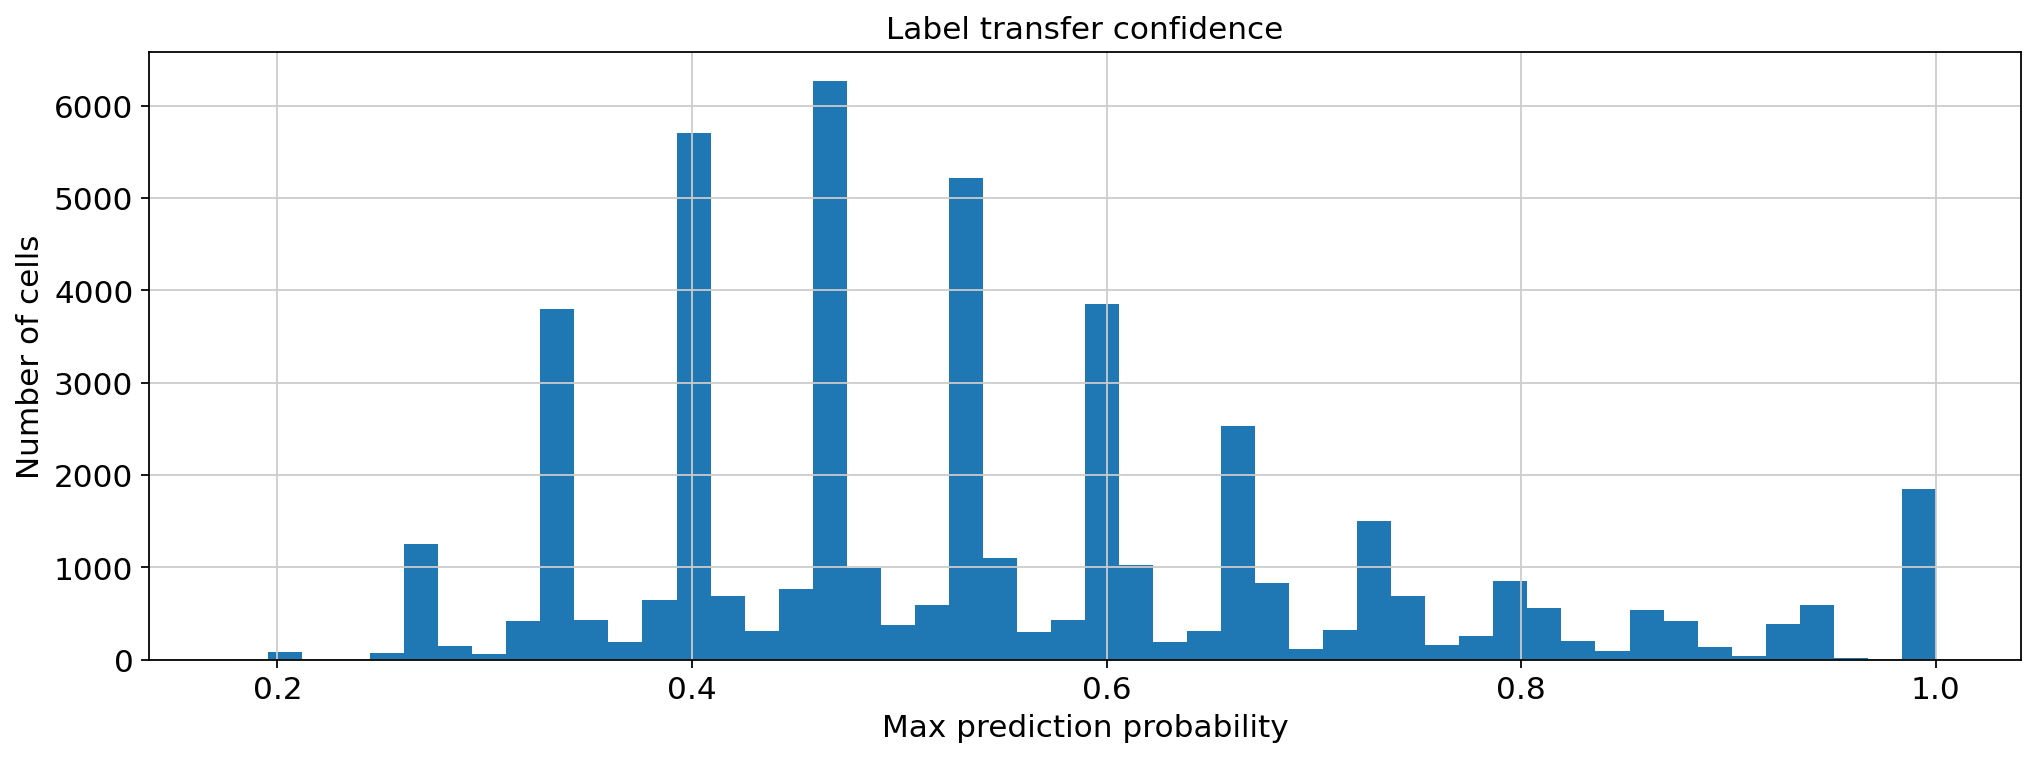

/home/manant1/.conda/envs/tf/lib/python3.9/site-packages/scipy/sparse/_index.py:146: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


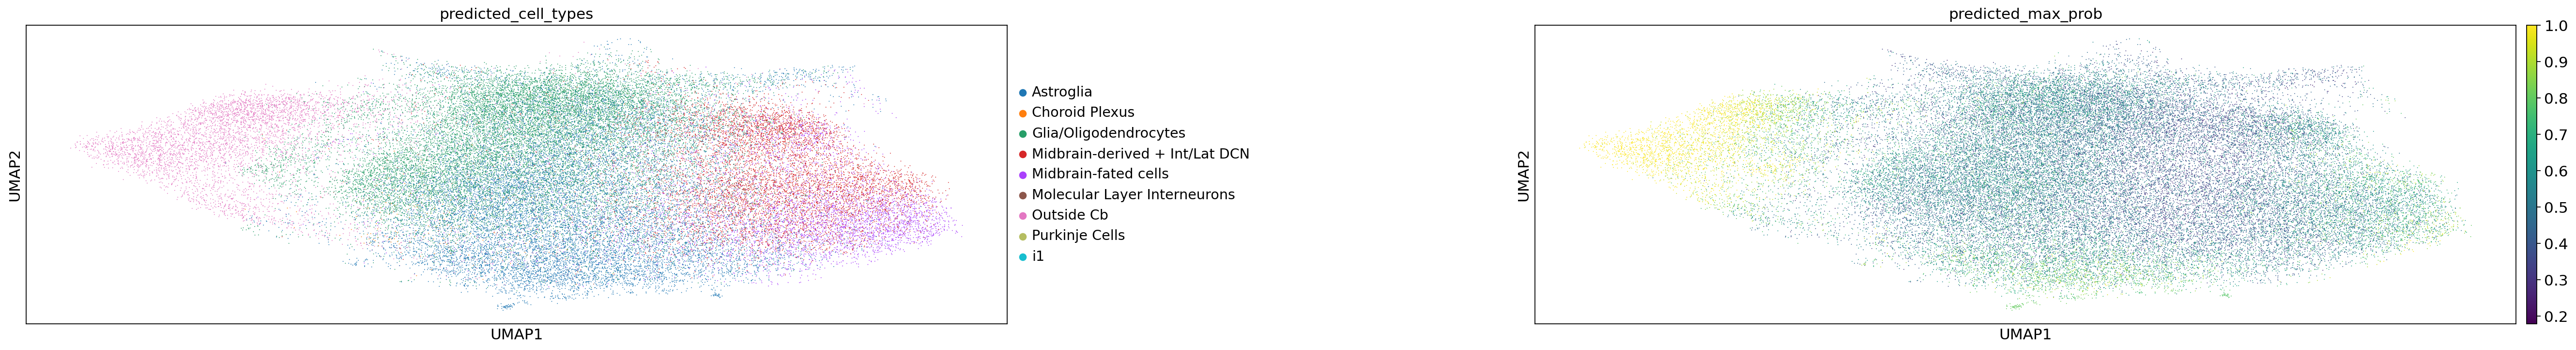

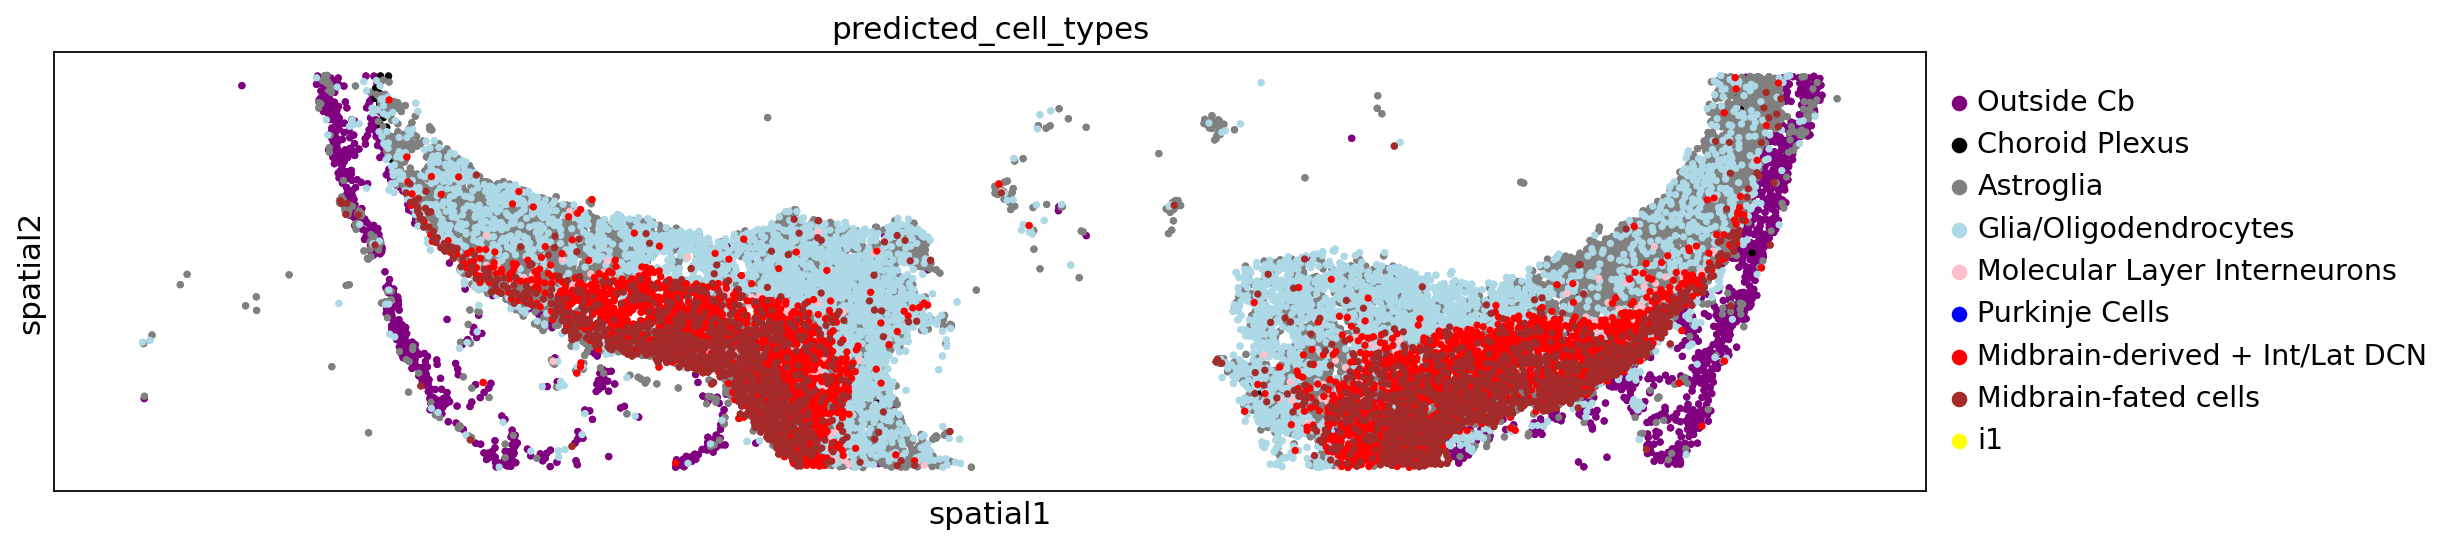

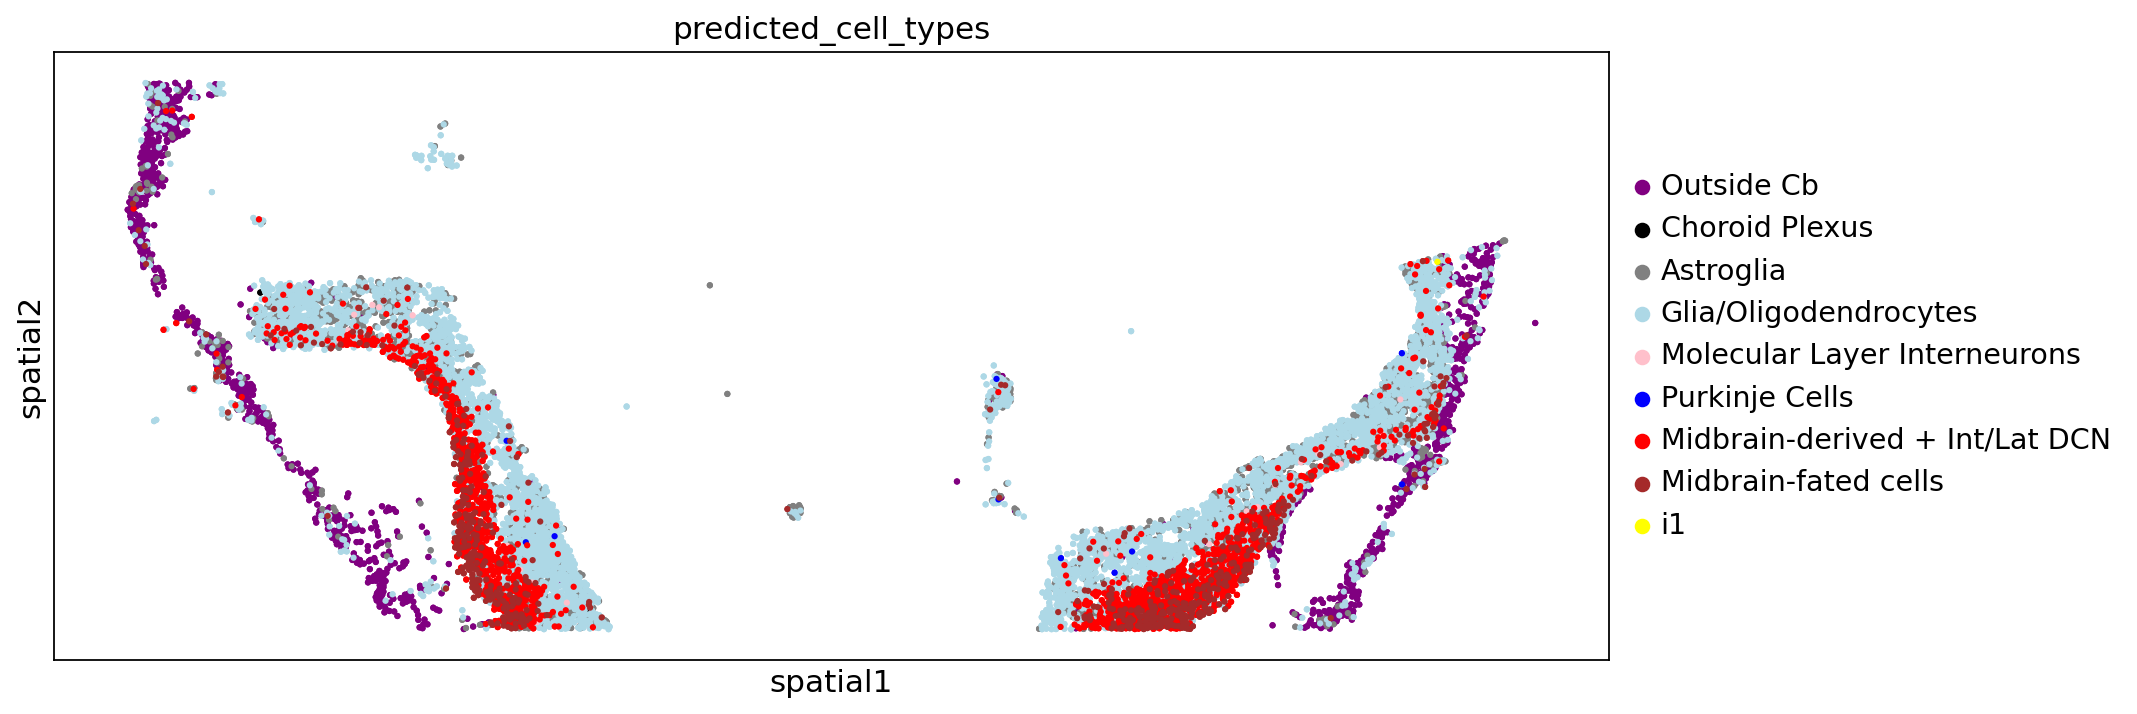

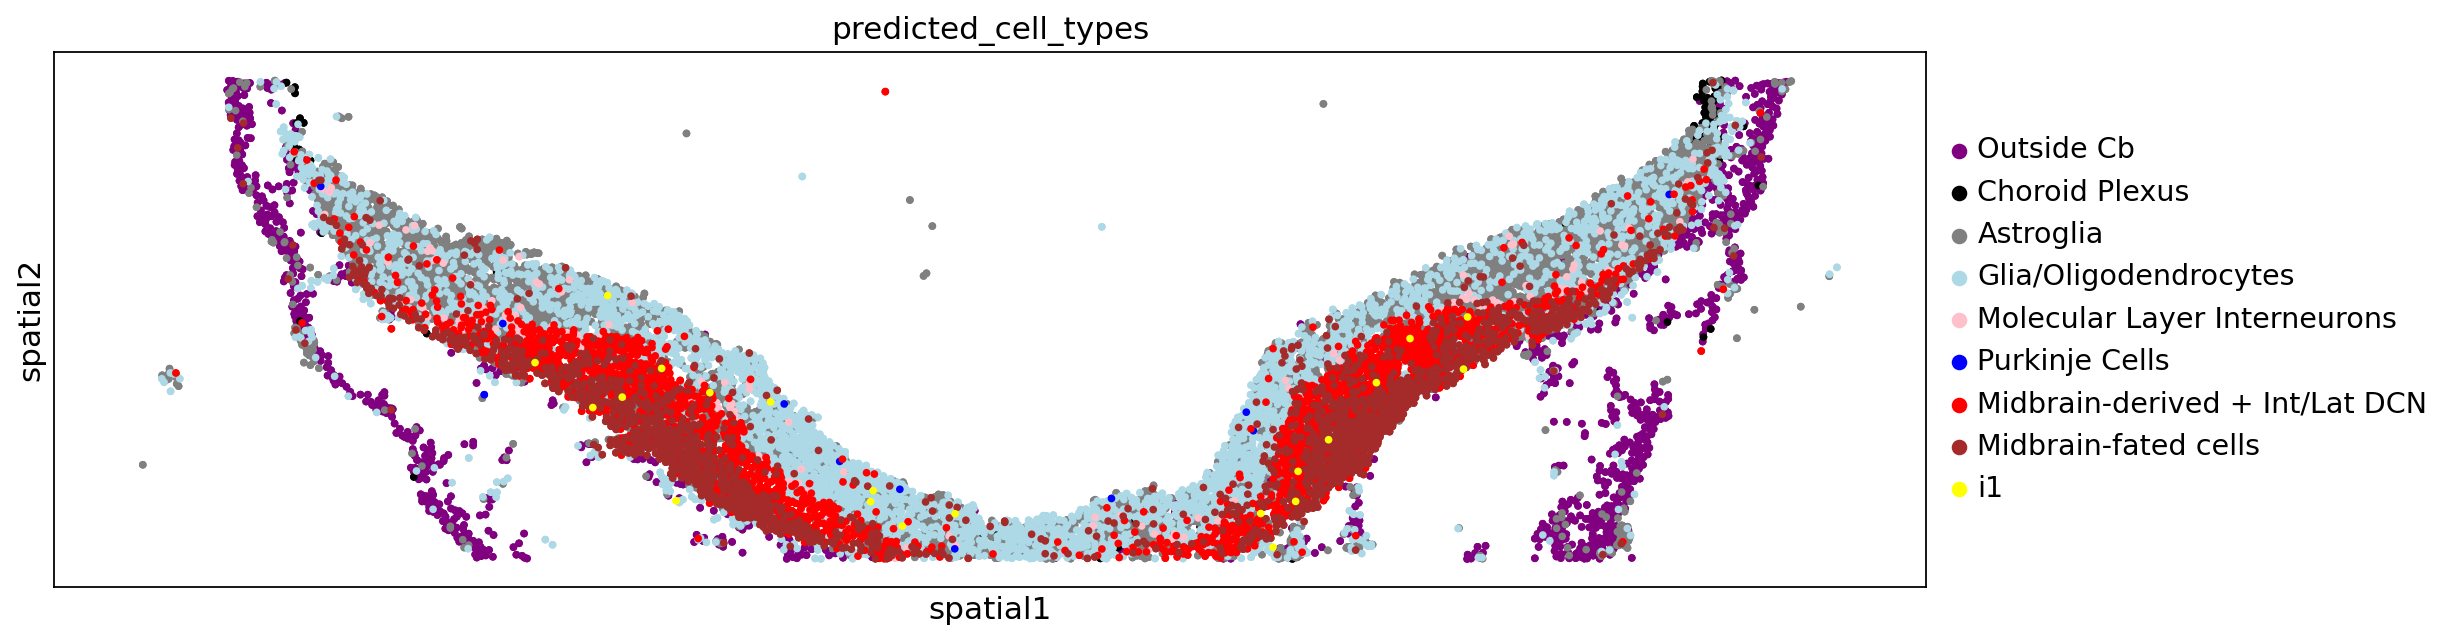

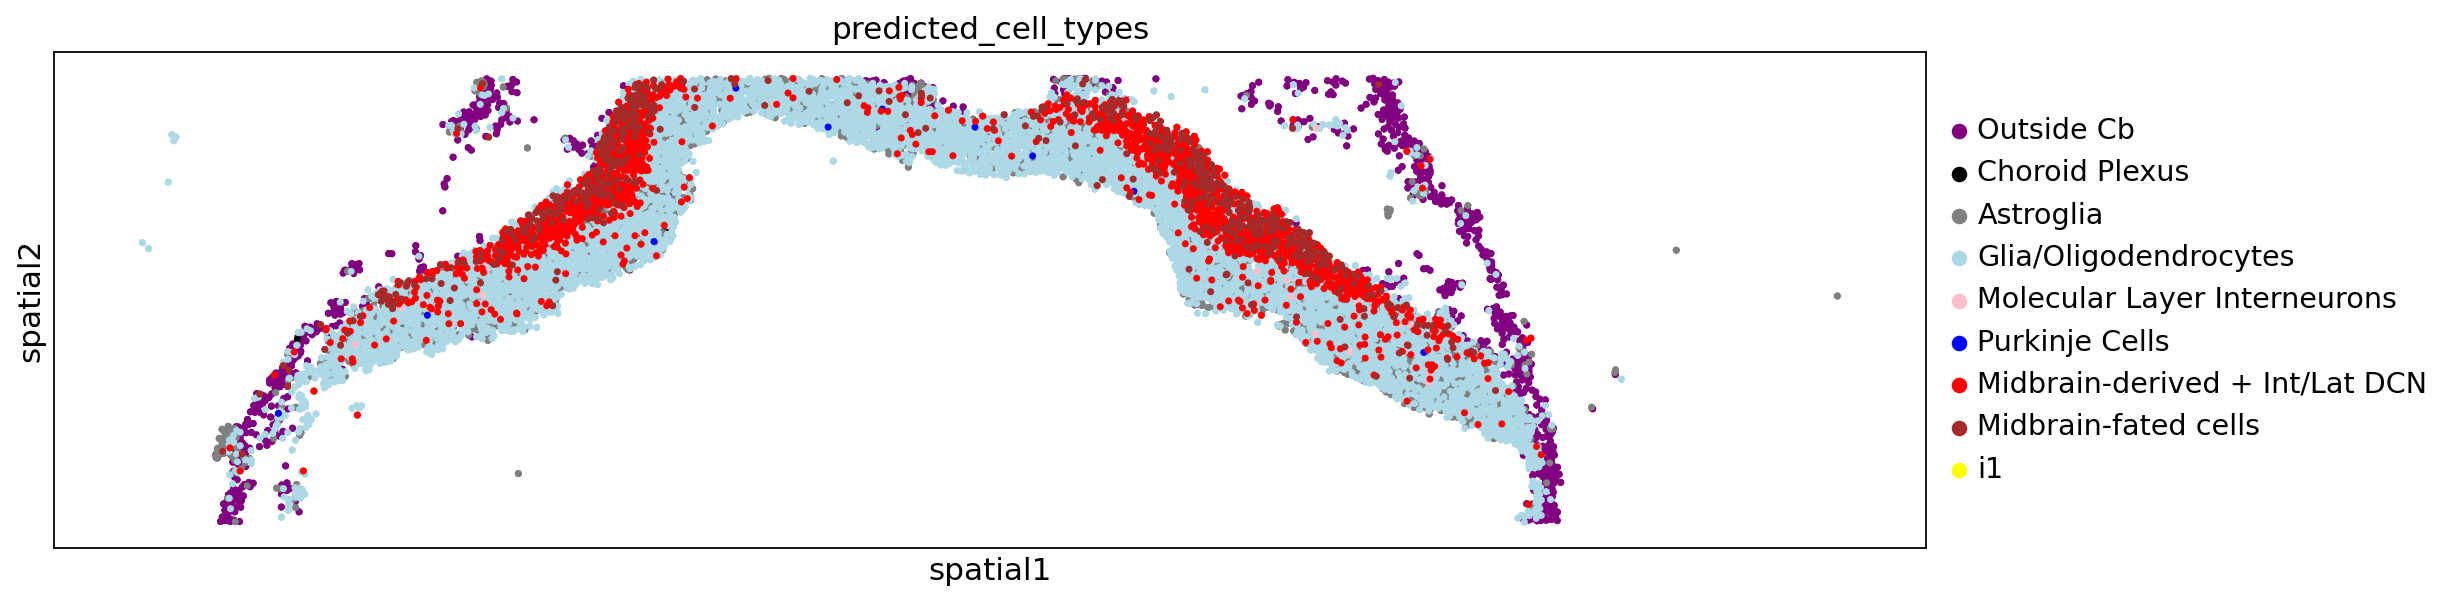

In [26]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.neighbors import KNeighborsClassifier
from scipy import sparse

# =========================================================
# 1. PREP REFERENCE + QUERY
# =========================================================
ref = e11_3_corr.copy()
query = adata.copy()

# keep only labeled ref cells
ref = ref[~ref.obs["cell_types"].isna()].copy()
ref.obs["cell_types"] = pd.Categorical(
    ref.obs["cell_types"].astype(str)
).remove_unused_categories()

# shared genes, same order
shared = ref.var_names.intersection(query.var_names)
ref = ref[:, shared].copy()
query = query[:, shared].copy()

# normalize + log
for x in [ref, query]:
    sc.pp.normalize_total(x)
    sc.pp.log1p(x)

# HVGs from reference only
sc.pp.highly_variable_genes(ref, n_top_genes=3000, flavor="seurat")
hvg = ref.var["highly_variable"].values

ref = ref[:, hvg].copy()
query = query[:, hvg].copy()

# dense matrices if needed
X_ref = ref.X.toarray() if sparse.issparse(ref.X) else np.asarray(ref.X)
X_query = query.X.toarray() if sparse.issparse(query.X) else np.asarray(query.X)

# =========================================================
# 2. SCALE USING REFERENCE STATS
# =========================================================
ref_means = X_ref.mean(axis=0)
ref_stds = X_ref.std(axis=0)
ref_stds[ref_stds == 0] = 1

X_ref_scaled = (X_ref - ref_means) / ref_stds
X_query_scaled = (X_query - ref_means) / ref_stds

ref.X = X_ref_scaled
query.X = X_query_scaled

# =========================================================
# 3. PCA ON REFERENCE, PROJECT QUERY INTO SAME PC SPACE
# =========================================================
sc.tl.pca(ref, n_comps=30)

X_ref_pca = ref.obsm["X_pca"]
loadings = ref.varm["PCs"][:, :30]   # genes x PCs
X_query_pca = X_query_scaled @ loadings

ref.obsm["X_pca_ref"] = X_ref_pca
query.obsm["X_pca_ref"] = X_query_pca

# =========================================================
# 4. KNN LABEL TRANSFER IN PC SPACE
# =========================================================
y_ref = ref.obs["cell_types"].astype(str).values

knn = KNeighborsClassifier(n_neighbors=15, weights="distance")
knn.fit(X_ref_pca, y_ref)

pred = knn.predict(X_query_pca)
probs = knn.predict_proba(X_query_pca)

query.obs["predicted_cell_types"] = pred
query.obs["predicted_max_prob"] = probs.max(axis=1)

# optional: reject low-confidence cells
threshold = 0.0
query.obs["predicted_cell_types"] = np.where(
    query.obs["predicted_max_prob"] < threshold,
    "Unknown",
    query.obs["predicted_cell_types"]
)

query.obs["predicted_cell_types"] = pd.Categorical(query.obs["predicted_cell_types"])

# quick checks
print(query.obs["predicted_cell_types"].value_counts())
print(query.obs["predicted_max_prob"].describe())

plt.hist(query.obs["predicted_max_prob"], bins=50)
plt.xlabel("Max prediction probability")
plt.ylabel("Number of cells")
plt.title("Label transfer confidence")
plt.show()

# =========================================================
# 5. OPTIONAL UMAP OF TRANSFERRED LABELS
# =========================================================
sc.pp.neighbors(query, use_rep="X_pca_ref", n_neighbors=15)
sc.tl.umap(query)

sc.pl.umap(
    query,
    color=["predicted_cell_types", "predicted_max_prob"],
    wspace=0.4
)

# =========================================================
# 6. COLOR MAP + PLOTTING STYLE
# =========================================================
custom_colors = {
    "Purkinje Cells": "blue",
    "Midbrain-derived + Int/Lat DCN": "red",
    "Medial DCN": "orange",
    "DCN": "orange",
    "Astroglia": "grey",
    "": "white",
    "Choroid Plexus": "black",
    "Granule cells": "green",
    "Midbrain-fated cells": "brown",
    "Molecular Layer Interneurons": "pink",
    "Outside Cb": "purple",
    "Glia/Oligodendrocytes": "lightblue",
    "i1": "yellow",
    "Unknown": "#BBBBBB",
}

desired_order = [
    "Outside Cb",
    "Choroid Plexus",
    "Astroglia",
    "Glia/Oligodendrocytes",
    "Molecular Layer Interneurons",
    "Granule cells",
    "DCN",
    "Purkinje Cells",
    "Midbrain-derived + Int/Lat DCN",
    "Medial DCN",
    "Midbrain-fated cells",
    "i1",
    "Unknown",
]

to_plot = [
    ("e11_1",  80,  "all_tp_e11"),
    ("e11_2",  80,  "all_tp_e12"),
    ("e11_3",  80,  "all_tp_e13"),
    ("e11_4", 80,  "all_tp_e14")
]

def set_colors(adata, key, color_map):
    adata.obs[key] = adata.obs[key].astype("category")
    cats = list(adata.obs[key].cat.categories)

    color_map = dict(color_map)
    for c in cats:
        if c not in color_map:
            color_map[c] = "#CCCCCC"

    adata.uns[f"{key}_colors"] = [mcolors.to_hex(color_map[c]) for c in cats]

def set_order(adata, key, desired_order):
    ct = adata.obs[key].astype("category")
    cur = list(ct.cat.categories)
    final_order = [c for c in desired_order if c in cur] + [c for c in cur if c not in desired_order]

    color_by_cat = dict(zip(cur, adata.uns[f"{key}_colors"]))
    adata.uns[f"{key}_colors"] = [color_by_cat[c] for c in final_order]
    adata.obs[key] = ct.cat.reorder_categories(final_order, ordered=True)

def spatial_overlay_in_order(
    ad, color="predicted_cell_types", order=None, spot_size=80,
    legend_loc="right margin", save=None, show=True
):
    ad.obs[color] = ad.obs[color].astype("category")

    cats_present = [c for c in ad.obs[color].cat.categories if (ad.obs[color] == c).any()]
    draw_order = [c for c in (order or cats_present) if c in cats_present]

    if not draw_order:
        print("[warn] no matching categories in this slice; drawing base only")
        sc.pl.spatial(ad, color=color, spot_size=spot_size, show=show)
        return

    # base layer
    sc.pl.spatial(
        ad,
        color=color,
        spot_size=spot_size,
        na_color="#DDDDDD",
        legend_loc=None,
        show=False
    )
    ax = plt.gca()

    # overlay each category in chosen order
    for g in draw_order:
        sc.pl.spatial(
            ad,
            color=color,
            groups=[g],
            spot_size=spot_size,
            na_color="none",
            ax=ax,
            legend_loc=None,
            title=None,
            show=False
        )

    # legend pass
    sc.pl.spatial(
        ad,
        color=color,
        spot_size=0,
        ax=ax,
        legend_loc=legend_loc,
        na_in_legend=False,
        show=False
    )

    if save:
        plt.savefig(save, bbox_inches="tight", dpi=300)
    if show:
        plt.show()
    plt.close()

# apply colors + order once to full query object
set_colors(query, "predicted_cell_types", custom_colors)
set_order(query, "predicted_cell_types", desired_order)

# =========================================================
# 7. PLOT ALL SLICES WITH SAME COLORS/ORDER
# =========================================================
sc.set_figure_params(figsize=(15, 5))

for lib_id, spot, suffix in to_plot:
    ad = query[query.obs["library_id"] == lib_id].copy()
    if ad.n_obs == 0:
        print(f"[warn] No cells for library_id={lib_id}, skipping")
        continue

    # preserve full global category order + colors
    ad.obs["predicted_cell_types"] = ad.obs["predicted_cell_types"].cat.set_categories(
        query.obs["predicted_cell_types"].cat.categories,
        ordered=True
    )
    ad.uns["predicted_cell_types_colors"] = query.uns["predicted_cell_types_colors"]

    spatial_overlay_in_order(
        ad,
        color="predicted_cell_types",
        order=desired_order,
        spot_size=spot,
        show=True,
        # save=f"{suffix}_predicted_overlay.pdf",
    )